<a href="https://colab.research.google.com/github/suckgitariuses/PCVK_Ganjil_2025/blob/main/Modul5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MODUL 5-Operasi Aritmatika dan Logika - Gamma Correction, Image Depth, PSNR, Average Denoising, Image Masking**

**F. TUGAS PRAKTIKUM**

1. buat gamma correction sesuai dengan petunjuk berikut

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


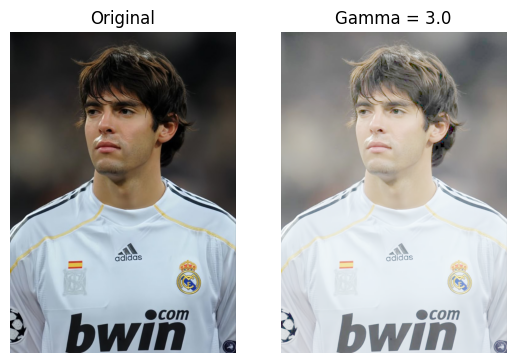

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except:
    print('Error, not a number')

# Membaca gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/ganteng.jpg')   # 0 = grayscale
if img is None:
    raise FileNotFoundError('File tidak ditemukan.')

# Rumus gamma correction: I’ = 255 * (I/255)^(1/gamma)
c = 255.0 / (255.0 ** (1.0/gamma))

# Menerapkan gamma correction pada tiap channel
gamma_img = c * (img.astype(np.float64) ** (1.0/gamma))
gamma_img = np.uint8(np.clip(gamma_img, 0, 255))

# Menampilkan hasil
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f'Gamma = {gamma}')
plt.imshow(cv2.cvtColor(gamma_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

2. buat simulasi image depth

 Simulasi Image Depth 
----------------------------------
Masukkan bit depth: 2


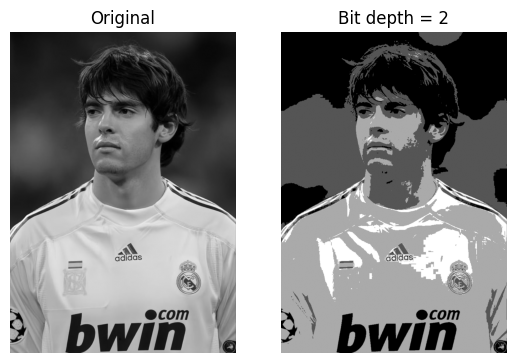

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(' Simulasi Image Depth ')
print('----------------------------------')
try:
    bit_depth = int(input('Masukkan bit depth: '))
except:
    print('Error, not a number')

# baca gambar grayscale
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/ganteng.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError('File tidak ditemukan.')

# hitung jarak antar-level
level = 255 / (pow(2, bit_depth) - 1)

# pre-alloc output sama shape
depth_img = np.zeros(img.shape, dtype=np.uint8)

# isi per-pixel
h, w = img.shape
for y in range(h):
    for x in range(w):
        val = img[y, x]
        q = np.round(val / level) * level
        if q < 0:
            q = 0
        elif q > 255:
            q = 255
        depth_img[y, x] = np.uint8(q)

# menampilkan hasil
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f'Bit depth = {bit_depth}')
plt.imshow(depth_img, cmap='gray')
plt.axis('off')
plt.show()

3. Buat Modul Average Denoising

In [4]:
import cv2
import numpy as np
import glob
import os

# fungsi PSNR
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# baca citra original
orig = cv2.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
if orig is None:
    raise FileNotFoundError('File original tidak ditemukan.')

# folder output untuk simpan noise
noise_dir = '/content/drive/MyDrive/PCVK/Images/noises/'
os.makedirs(noise_dir, exist_ok=True)

# buat 100 citra noise
num_noises = 100
for i in range(num_noises):
    noise = np.random.normal(0, 25, orig.shape).astype(np.float64)  # mean=0, std=25
    noisy_img = orig.astype(np.float64) + noise
    noisy_img = np.uint8(np.clip(noisy_img, 0, 255))
    cv2.imwrite(f'{noise_dir}noise_{i+1}.jpg', noisy_img)

print("100 citra noise berhasil dibuat.")

# baca smua citra noise
files = glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg')
files.sort()

jumlah = [5, 10, 20, 40, 80, 100]
for n in jumlah:
    acc = np.zeros(orig.shape, dtype=np.float64)
    for f in files[:n]:
        im = cv2.imread(f).astype(np.float64)
        acc += im
    avg = acc / n
    avg_img = np.uint8(np.clip(avg, 0, 255))
    psnr = PSNR(orig, avg_img)
    print(f'Jumlah citra = {n}, PSNR = {psnr:.2f} dB')
    # buat direktori jika output belum ada
    output_dir = '/content/drive/MyDrive/PCVK/Images/output/'
    os.makedirs(output_dir, exist_ok=True)
    cv2.imwrite(f'{output_dir}average_{n}.png', avg_img)

100 citra noise berhasil dibuat.
Jumlah citra = 5, PSNR = 30.47 dB
Jumlah citra = 10, PSNR = 33.11 dB
Jumlah citra = 20, PSNR = 35.42 dB
Jumlah citra = 40, PSNR = 37.31 dB
Jumlah citra = 80, PSNR = 38.69 dB
Jumlah citra = 100, PSNR = 39.03 dB


4. buat image masking untuk image berikut. image kiri adalah image asli sedangkan image kanan adalah hasilnya.

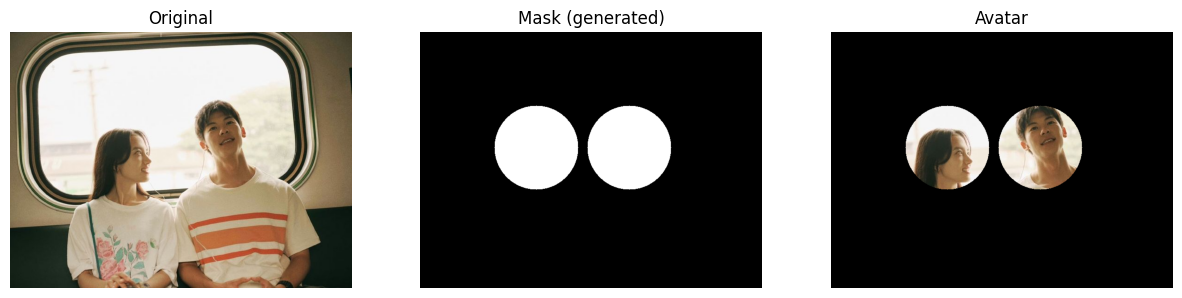

True

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar asli
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')  # ubah nama jika beda
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Buat mask kosong (hitam)
mask = np.zeros(img.shape[:2], dtype=np.uint8)

# Tambahkan dua lingkaran putih (mask area)
cv2.circle(mask, (250, 250), 90, (255), -1)
cv2.circle(mask, (450, 250), 90, (255), -1)

# Ubah mask ke 3 channel agar cocok dengan gambar berwarna
mask3 = cv2.merge([mask, mask, mask])

# Lakukan masking dengan operasi AND
avatar = cv2.bitwise_and(img, mask3)

# Tampilkan hasil
plt.figure(figsize=(15,15))
plt.subplot(1,3,1); plt.title('Original'); plt.imshow(img); plt.axis('off')
plt.subplot(1,3,2); plt.title('Mask (generated)'); plt.imshow(mask, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title('Avatar'); plt.imshow(avatar); plt.axis('off')
plt.show()

# Simpan hasil
cv2.imwrite('/content/drive/MyDrive/PCVK/Images/avatarMasking.png', cv2.cvtColor(avatar, cv2.COLOR_RGB2BGR))


5. lakukan percobaan menggunakan operator lain dan tunjukkan hasilnya pada modul ini.

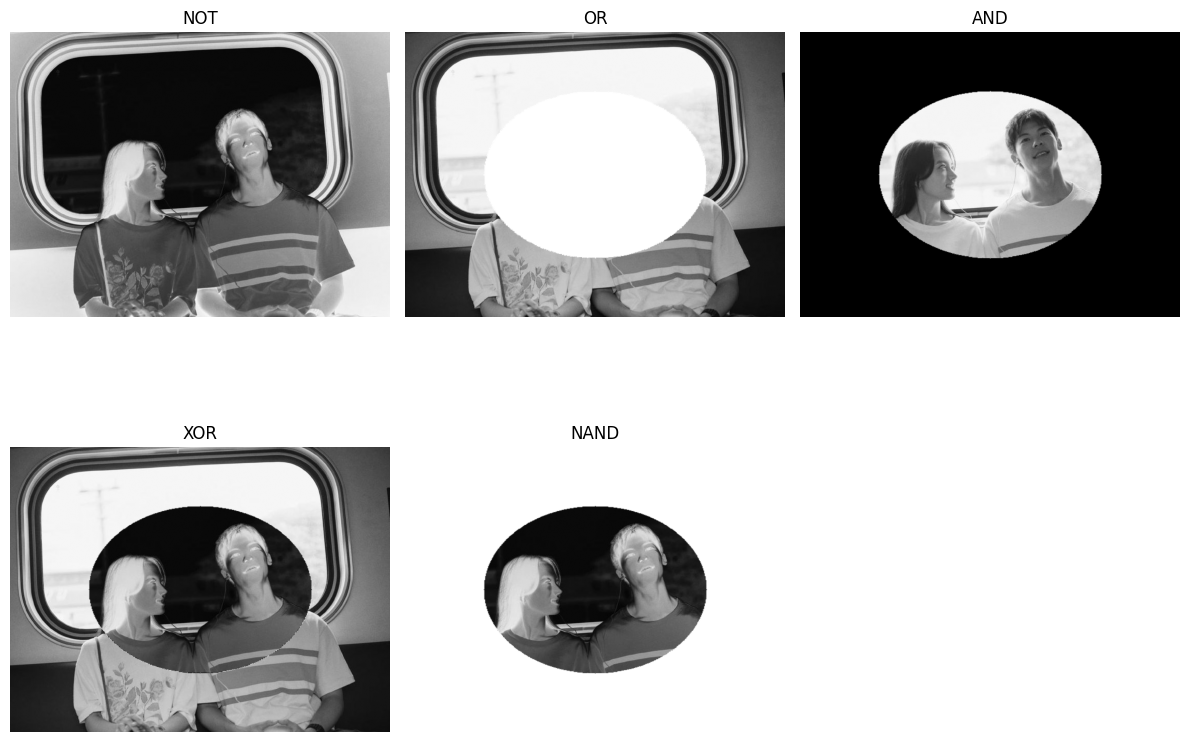

In [24]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Path citra asli & mask
img1_path = '/content/drive/MyDrive/PCVK/Images/couple.tiff'   # ganti sesuai file kamu
img2_path = '/content/drive/MyDrive/PCVK/Images/mask.tiff'

# Baca citra grayscale
img1 = cv.imread(img1_path, 0)
img2 = cv.imread(img2_path, 0)

if img1 is None:
    raise FileNotFoundError(f'Citra asli tidak ditemukan di {img1_path}')
if img2 is None:
    raise FileNotFoundError(f'Mask tidak ditemukan di {img2_path}')

# Samakan ukuran
if img1.shape != img2.shape:
    img2 = cv.resize(img2, (img1.shape[1], img1.shape[0]))

# 🔹 Operasi logika
and_img = cv.bitwise_and(img1, img2)
or_img = cv.bitwise_or(img1, img2)
not_img = cv.bitwise_not(img1)
xor_img = cv.bitwise_xor(img1, img2)
nand_img = cv.bitwise_not(and_img)

# 🔹 Susun hasil dengan urutan yang rapi
titles = ['NOT', 'OR', 'AND', 'XOR', 'NAND']
images = [not_img, or_img, and_img, xor_img, nand_img]

# 🔹 Tampilkan hasil
plt.figure(figsize=(12, 9))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
